# Лабораторная работа: Подготовка обучающей и тестовой выборки, кросс-валидация и подбор гиперпараметров на примере метода ближайших соседей

## Цель лабораторной работы:
Изучение способов подготовки выборки и подбора гиперпараметров на примере метода ближайших соседей.

## Задание:
1. Выберите набор данных (датасет) для решения задачи классификации или регрессии.
2. В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
3. С использованием метода `train_test_split` разделите выборку на обучающую и тестовую.
4. Обучите модель ближайших соседей для произвольно заданного гиперпараметра K. Оцените качество модели с помощью подходящих для задачи метрик.
5. Произведите подбор гиперпараметра K с использованием `GridSearchCV` и `RandomizedSearchCV` и кросс-валидации, оцените качество оптимальной модели. Используйте не менее двух стратегий кросс-валидации.
6. Сравните метрики качества исходной и оптимальной моделей.

Выполним импорт необходимых библиотек

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

Загрузка и первичный анализ

In [4]:
df = sns.load_dataset('titanic')
print('Первые пять строк')
print(df.head())
print(f"\nТипы данных и пропуски:")
print(df.info())

print(f"\nСтатистика числовых признаков:")
print(df.describe())

print("Распределение целевой переменной (выжил/не выжил):")
print(df['survived'].value_counts())

Первые пять строк
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       ----------

Проверим на наличие пропусков

In [5]:
df_processed = df.copy()

print("Исходное количество пропусков:")
print(df_processed.isnull().sum())

# Удаляем: 'alive' (дублирует survived), 'deck' (много пропусков), 
# 'class' (дублирует pclass), 'who' (дублирует sex и age), 
# 'adult_male' (дублирует sex и age), 'embark_town' (дублирует embarked)
columns_to_drop = ['alive', 'deck', 'class', 'who', 'adult_male', 'embark_town']
df_processed = df_processed.drop(columns=columns_to_drop)

print("Признаки после удаления дублирующих колонок:")
print(df_processed.columns.tolist())


Исходное количество пропусков:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
Признаки после удаления дублирующих колонок:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


Заполняем пропуска. Age заполним медианой, а embarked - модой.

In [6]:
age_medians = df_processed.groupby(['sex', 'pclass'])['age'].median()
for (sex, pclass), median_age in age_medians.items():
    mask = (df_processed['sex'] == sex) & (df_processed['pclass'] == pclass) & (df_processed['age'].isnull())
    df_processed.loc[mask, 'age'] = median_age

embarked_mode = df_processed['embarked'].mode()[0]
df_processed['embarked'] = df_processed['embarked'].fillna(embarked_mode)
print(f"Пропуски после заполнения возраста: {df_processed['age'].isnull().sum()}")
print(f"Пропуски после заполнения порта посадки: {df_processed['embarked'].isnull().sum()}")

Пропуски после заполнения возраста: 0
Пропуски после заполнения порта посадки: 0


Далее кодируем категориальные признаки

In [7]:
# LabelEncoder для sex (male/female)
le_sex = LabelEncoder()
df_processed['sex_encoded'] = le_sex.fit_transform(df_processed['sex'])

# One-hot кодирование для embarked
embarked_dummies = pd.get_dummies(df_processed['embarked'], prefix='embarked', drop_first=True)
df_processed = pd.concat([df_processed, embarked_dummies], axis=1)

# Кодирование alone (True/False -> 1/0)
df_processed['alone_encoded'] = df_processed['alone'].astype(int)

# Удаляем исходные текстовые колонки, которые больше не нужны
df_processed = df_processed.drop(columns=['sex', 'embarked', 'alone'])

print("Признаки после кодирования:")
print(df_processed.columns.tolist())
print(df_processed.head())

Признаки после кодирования:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_encoded', 'embarked_Q', 'embarked_S', 'alone_encoded']
   survived  pclass   age  sibsp  parch     fare  sex_encoded  embarked_Q  \
0         0       3  22.0      1      0   7.2500            1       False   
1         1       1  38.0      1      0  71.2833            0       False   
2         1       3  26.0      0      0   7.9250            0       False   
3         1       1  35.0      1      0  53.1000            0       False   
4         0       3  35.0      0      0   8.0500            1       False   

   embarked_S  alone_encoded  
0        True              0  
1       False              0  
2        True              1  
3        True              0  
4        True              1  


Выбираем признаки для модели

In [8]:
feature_columns = ['pclass', 'age', 'sibsp', 'parch', 'fare', 
                   'sex_encoded', 'alone_encoded', 'embarked_Q', 'embarked_S']

X = df_processed[feature_columns]
y = df_processed['survived']

print("Признаки для модели (X):")
print(X.head())
print(f"\nРазмерность X: {X.shape}")
print(f"Размерность y: {y.shape}")

Признаки для модели (X):
   pclass   age  sibsp  parch     fare  sex_encoded  alone_encoded  \
0       3  22.0      1      0   7.2500            1              0   
1       1  38.0      1      0  71.2833            0              0   
2       3  26.0      0      0   7.9250            0              1   
3       1  35.0      1      0  53.1000            0              0   
4       3  35.0      0      0   8.0500            1              1   

   embarked_Q  embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  

Размерность X: (891, 9)
Размерность y: (891,)


Масштабируем признаки

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)

print("Статистика признаков после масштабирования:")
print(X_scaled_df.describe())

Статистика признаков после масштабирования:
             pclass           age         sibsp         parch          fare  \
count  8.910000e+02  8.910000e+02  8.910000e+02  8.910000e+02  8.910000e+02   
mean  -8.772133e-17  2.153160e-16  4.386066e-17  5.382900e-17  3.987333e-18   
std    1.000562e+00  1.000562e+00  1.000562e+00  1.000562e+00  1.000562e+00   
min   -1.566107e+00 -2.157819e+00 -4.745452e-01 -4.736736e-01 -6.484217e-01   
25%   -3.693648e-01 -5.724938e-01 -4.745452e-01 -4.736736e-01 -4.891482e-01   
50%    8.273772e-01 -2.340704e-01 -4.745452e-01 -4.736736e-01 -3.573909e-01   
75%    8.273772e-01  5.179814e-01  4.327934e-01 -4.736736e-01 -2.424635e-02   
max    8.273772e-01  3.827009e+00  6.784163e+00  6.974147e+00  9.667167e+00   

        sex_encoded  alone_encoded  embarked_Q    embarked_S  
count  8.910000e+02   8.910000e+02  891.000000  8.910000e+02  
mean  -1.156327e-16  -6.379733e-17    0.000000 -8.373399e-17  
std    1.000562e+00   1.000562e+00    1.000562  1.00056

Разделим данные на обучающую (80%) и тестовую (20%) выборки с сохранением пропорций классов.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки X_train: {X_train.shape}")
print(f"Размер тестовой выборки X_test: {X_test.shape}")
print(f"Размер обучающей выборки y_train: {y_train.shape}")
print(f"Размер тестовой выборки y_test: {y_test.shape}")

print("\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts(normalize=True))
print("\nРаспределение классов в тестовой выборке:")
print(y_test.value_counts(normalize=True))

Размер обучающей выборки X_train: (712, 9)
Размер тестовой выборки X_test: (179, 9)
Размер обучающей выборки y_train: (712,)
Размер тестовой выборки y_test: (179,)

Распределение классов в обучающей выборке:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Распределение классов в тестовой выборке:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


Обучим модель с произвольным значением K=8 и оценим её качество.

Качество модели с произвольным K = 8:

Accuracy: 0.7933
Precision (macro avg): 0.7941
Recall (macro avg): 0.7616
F1-score (macro avg): 0.7709

Отчет по классификации:
              precision    recall  f1-score   support

    Не выжил       0.79      0.90      0.84       110
       Выжил       0.80      0.62      0.70        69

    accuracy                           0.79       179
   macro avg       0.79      0.76      0.77       179
weighted avg       0.79      0.79      0.79       179



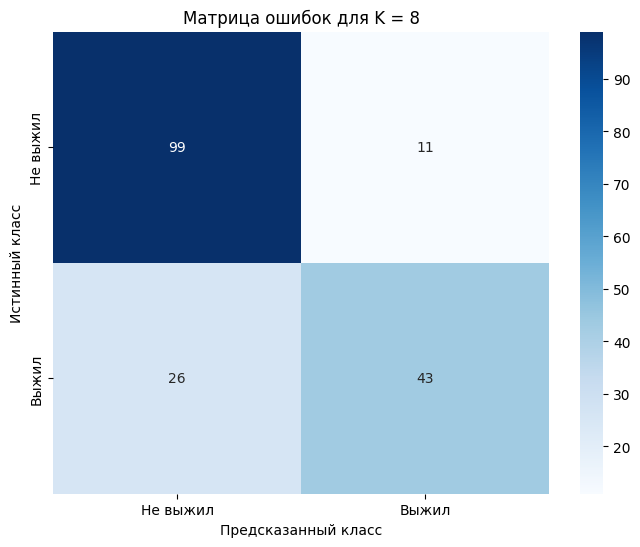

In [11]:
k_arbitrary = 8

knn_arbitrary = KNeighborsClassifier(n_neighbors=k_arbitrary)
knn_arbitrary.fit(X_train, y_train)

y_pred_arbitrary = knn_arbitrary.predict(X_test)

print("="*60)
print(f"Качество модели с произвольным K = {k_arbitrary}:")
print("="*60)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_arbitrary):.4f}")
print(f"Precision (macro avg): {precision_score(y_test, y_pred_arbitrary, average='macro'):.4f}")
print(f"Recall (macro avg): {recall_score(y_test, y_pred_arbitrary, average='macro'):.4f}")
print(f"F1-score (macro avg): {f1_score(y_test, y_pred_arbitrary, average='macro'):.4f}")

print("\n" + "="*60)
print("Отчет по классификации:")
print("="*60)
print(classification_report(y_test, y_pred_arbitrary, target_names=['Не выжил', 'Выжил']))

# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_arbitrary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Не выжил', 'Выжил'], 
            yticklabels=['Не выжил', 'Выжил'])
plt.title(f'Матрица ошибок для K = {k_arbitrary}')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

# Подбор гиперпараметра K с использованием GridSearchCV и RandomizedSearchCV
Используем две стратегии кросс-валидации: KFold и StratifiedKFold.

GridSearchCV выполняет исчерпывающий поиск по заданной сетке значений гиперпараметров.


GridSearchCV с KFold (5-fold):
Лучшее значение K: 4
Лучшая точность на кросс-валидации: 0.8076

GridSearchCV со StratifiedKFold (5-fold):
Лучшее значение K: 5
Лучшая точность на кросс-валидации: 0.8090


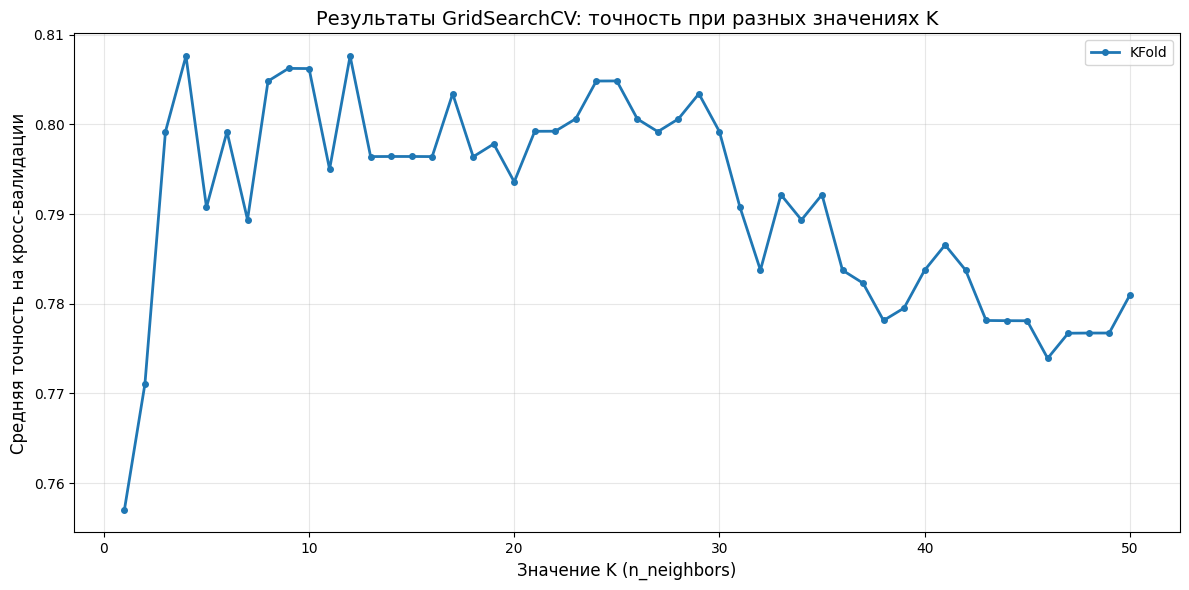

In [12]:
# Определение диапазона значений для K
param_grid = {'n_neighbors': list(range(1, 51))}

# 1. KFold кросс-валидация
kf = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search_kf = GridSearchCV(
    KNeighborsClassifier(), 
    param_grid, 
    cv=kf, 
    scoring='accuracy', 
    n_jobs=-1
)
grid_search_kf.fit(X_train, y_train)

print(f"\nGridSearchCV с KFold (5-fold):")
print(f"Лучшее значение K: {grid_search_kf.best_params_['n_neighbors']}")
print(f"Лучшая точность на кросс-валидации: {grid_search_kf.best_score_:.4f}")

# 2. StratifiedKFold кросс-валидация (лучше для несбалансированных данных)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_skf = GridSearchCV(
    KNeighborsClassifier(), 
    param_grid, 
    cv=skf, 
    scoring='accuracy', 
    n_jobs=-1
)
grid_search_skf.fit(X_train, y_train)

print(f"\nGridSearchCV со StratifiedKFold (5-fold):")
print(f"Лучшее значение K: {grid_search_skf.best_params_['n_neighbors']}")
print(f"Лучшая точность на кросс-валидации: {grid_search_skf.best_score_:.4f}")

# Визуализация результатов GridSearchCV
results_kf = pd.DataFrame(grid_search_kf.cv_results_)

plt.figure(figsize=(12, 6))
plt.plot(results_kf['param_n_neighbors'], results_kf['mean_test_score'], 
         marker='o', linestyle='-', linewidth=2, markersize=4, label='KFold')
plt.xlabel('Значение K (n_neighbors)', fontsize=12)
plt.ylabel('Средняя точность на кросс-валидации', fontsize=12)
plt.title('Результаты GridSearchCV: точность при разных значениях K', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Подбор K с помощью RandomizedSearchCV

RandomizedSearchCV выбирает случайные комбинации гиперпараметров из заданного распределения.

In [22]:
from scipy.stats import randint

param_dist = {'n_neighbors': list(range(1, 51))}

# 1. KFold кросс-валидация
rand_search_kf = RandomizedSearchCV(
    KNeighborsClassifier(), 
    param_distributions=param_dist, 
    cv=kf, 
    scoring='accuracy', 
    n_iter=20, 
    random_state=42, 
    n_jobs=-1
)
rand_search_kf.fit(X_train, y_train)

print(f"\nRandomizedSearchCV с KFold (5-fold):")
print(f"Лучшее значение K: {rand_search_kf.best_params_['n_neighbors']}")
print(f"Лучшая точность на кросс-валидации: {rand_search_kf.best_score_:.4f}")

# 2. StratifiedKFold кросс-валидация
rand_search_skf = RandomizedSearchCV(
    KNeighborsClassifier(), 
    param_distributions=param_dist, 
    cv=skf, 
    scoring='accuracy', 
    n_iter=20, 
    random_state=42, 
    n_jobs=-1
)
rand_search_skf.fit(X_train, y_train)

print(f"\nRandomizedSearchCV со StratifiedKFold (5-fold):")
print(f"Лучшее значение K: {rand_search_skf.best_params_['n_neighbors']}")
print(f"Лучшая точность на кросс-валидации: {rand_search_skf.best_score_:.4f}")


RandomizedSearchCV с KFold (5-fold):
Лучшее значение K: 4
Лучшая точность на кросс-валидации: 0.8076

RandomizedSearchCV со StratifiedKFold (5-fold):
Лучшее значение K: 5
Лучшая точность на кросс-валидации: 0.8090


Оптимальное значение K (из GridSearchCV + StratifiedKFold): 5

Качество оптимальной модели с K = 5:

Accuracy: 0.7989
Precision (macro avg): 0.7904
Recall (macro avg): 0.7796
F1-score (macro avg): 0.7840

Отчет по классификации для оптимальной модели:
              precision    recall  f1-score   support

    Не выжил       0.82      0.86      0.84       110
       Выжил       0.76      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



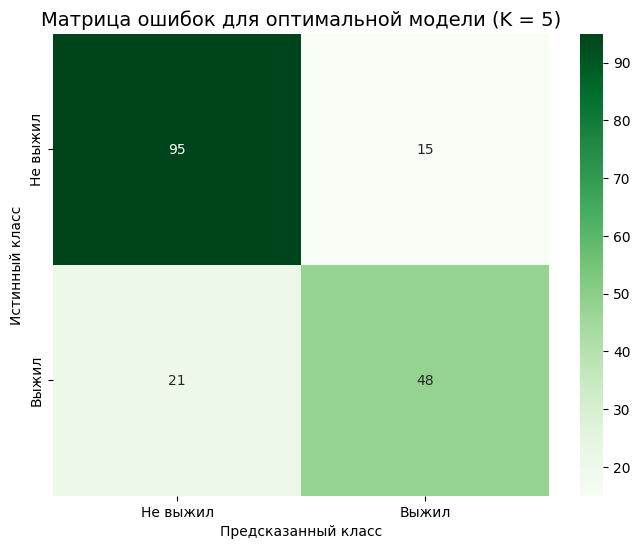

In [14]:
best_k = grid_search_skf.best_params_['n_neighbors']
print(f"Оптимальное значение K (из GridSearchCV + StratifiedKFold): {best_k}")

knn_optimal = KNeighborsClassifier(n_neighbors=best_k)
knn_optimal.fit(X_train, y_train)

y_pred_optimal = knn_optimal.predict(X_test)

print("\n" + "="*60)
print(f"Качество оптимальной модели с K = {best_k}:")
print("="*60)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_optimal):.4f}")
print(f"Precision (macro avg): {precision_score(y_test, y_pred_optimal, average='macro'):.4f}")
print(f"Recall (macro avg): {recall_score(y_test, y_pred_optimal, average='macro'):.4f}")
print(f"F1-score (macro avg): {f1_score(y_test, y_pred_optimal, average='macro'):.4f}")

print("\n" + "="*60)
print("Отчет по классификации для оптимальной модели:")
print("="*60)
print(classification_report(y_test, y_pred_optimal, target_names=['Не выжил', 'Выжил']))

plt.figure(figsize=(8, 6))
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Не выжил', 'Выжил'], 
            yticklabels=['Не выжил', 'Выжил'])
plt.title(f'Матрица ошибок для оптимальной модели (K = {best_k})', fontsize=14)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

Сравнение метрик качества моделей
           Модель  Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)
   Исходная (K=8)  0.793296           0.794148        0.761594           0.77087
Оптимальная (K=5)  0.798883           0.790435        0.779644           0.78399



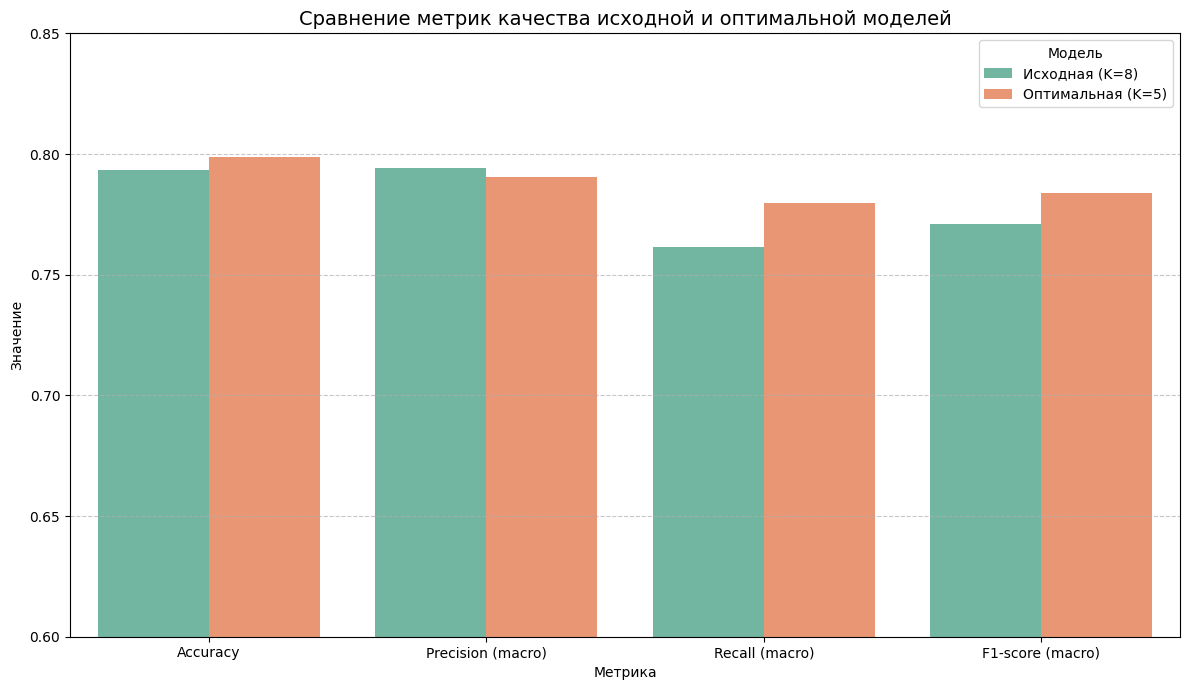


Изменение метрик при переходе к оптимальной модели:
Accuracy: 0.7933 → 0.7989 (+0.56%)
Precision (macro): 0.7941 → 0.7904 (-0.37%)
Recall (macro): 0.7616 → 0.7796 (+1.81%)
F1-score (macro): 0.7709 → 0.7840 (+1.31%)


In [15]:
metrics_comparison = {
    'Модель': ['Исходная (K=8)', 'Оптимальная (K={})'.format(best_k)],
    'Accuracy': [
        accuracy_score(y_test, y_pred_arbitrary), 
        accuracy_score(y_test, y_pred_optimal)
    ],
    'Precision (macro)': [
        precision_score(y_test, y_pred_arbitrary, average='macro'), 
        precision_score(y_test, y_pred_optimal, average='macro')
    ],
    'Recall (macro)': [
        recall_score(y_test, y_pred_arbitrary, average='macro'), 
        recall_score(y_test, y_pred_optimal, average='macro')
    ],
    'F1-score (macro)': [
        f1_score(y_test, y_pred_arbitrary, average='macro'), 
        f1_score(y_test, y_pred_optimal, average='macro')
    ]
}

comparison_df = pd.DataFrame(metrics_comparison)
print("="*60)
print("Сравнение метрик качества моделей")
print("="*60)
print(comparison_df.to_string(index=False))
print("\n" + "="*60)

comparison_melted = comparison_df.melt(id_vars='Модель', var_name='Метрика', value_name='Значение')

plt.figure(figsize=(12, 7))
sns.barplot(x='Метрика', y='Значение', hue='Модель', data=comparison_melted, palette='Set2')
plt.title('Сравнение метрик качества исходной и оптимальной моделей', fontsize=14)
plt.ylim(0.6, 0.85)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Модель')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Изменение метрик при переходе к оптимальной модели:")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_arbitrary):.4f} → {accuracy_score(y_test, y_pred_optimal):.4f} "
      f"({(accuracy_score(y_test, y_pred_optimal) - accuracy_score(y_test, y_pred_arbitrary))*100:+.2f}%)")
print(f"Precision (macro): {precision_score(y_test, y_pred_arbitrary, average='macro'):.4f} → {precision_score(y_test, y_pred_optimal, average='macro'):.4f} "
      f"({(precision_score(y_test, y_pred_optimal, average='macro') - precision_score(y_test, y_pred_arbitrary, average='macro'))*100:+.2f}%)")
print(f"Recall (macro): {recall_score(y_test, y_pred_arbitrary, average='macro'):.4f} → {recall_score(y_test, y_pred_optimal, average='macro'):.4f} "
      f"({(recall_score(y_test, y_pred_optimal, average='macro') - recall_score(y_test, y_pred_arbitrary, average='macro'))*100:+.2f}%)")
print(f"F1-score (macro): {f1_score(y_test, y_pred_arbitrary, average='macro'):.4f} → {f1_score(y_test, y_pred_optimal, average='macro'):.4f} "
      f"({(f1_score(y_test, y_pred_optimal, average='macro') - f1_score(y_test, y_pred_arbitrary, average='macro'))*100:+.2f}%)")